# Partie 2  - Interpolation polynômiale 


<div style="color:#ff0000;font-family:courier; font-size:100%; font-weight:bold;">
    
### Eléments de réponse  pour le sujet proposé:

**Seules les parties dont les réponses sont attendues sur le notebook sont concernées par la réponse.**
</div> 
    

<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;">
    
 >-   Les réponses attendues sont données dans cette fonte.
</div>
  
<div style="color:#6a0eba;font-family:courier; font-size:100%; font-weight:bold;">
    
 >-   Les commentaires ou remarques sont donnés dans cette fonte. 
    
 >-   Sont fournies aussi dans cette fonte les réponses aux questions théoriques absolument nécessaires pour résoudre la partie pratique.
</div>

---
 > # =============== DEBUT ====================
---

### ATTENTION: 
> ####  Les questions théoriques sont à faire sur copies d'examen. Elles sont rappelées dans l'énoncé.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt 

## Exercice 1 : Questions de cours :  Définition du polynôme d'interpolation de Lagrange


#### Question 1-1 :  Cette partie est à faire sur copie d'examen

On considère la base de Lagrangre $L_0, L_1, \ldots L_n $ associée aux points 2 à 2 distincts $x_0, x_1,  \ldots, x_n $.
> Montrer que pour tout $x$ dans $\mathbb{R}$ on a :

>> 1. $\quad \displaystyle \sum_{i=0}^{n}  x_{i}^{k} \, L_i(x) = x^k, \quad k=0,  \ldots, n$

>> 2. $\quad \displaystyle \sum_{i=0}^{n} x_{i}^{n+1} \, L_i(x) = x^{n+1} - \prod_{i=0}^n (x - x_i) $

<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;">

> - On connait le résultat d'estimation d'erreur (*voir cours*):  pour ces $n$ points $x_i, i= 0,\ldots,n$, 
 qu'on peut supposer dans l'intervalle $[a, b]$  (il suffit de prendre a  respectivement le plus petit respectivement 
 le plus grand des $x_i$)

 $\exists t \in ]a,b[$ tel que 

 $$
  \quad \displaystyle  f(x) - \sum_{i=0}^{n} f(x_{i}) \, L_i(x) = \frac{f^{n+1}(t)}{(n+1) !} \prod_{i=0}^n (x - x_i) 
 $$
 D'où

 $$
  \quad \displaystyle  \sum_{i=0}^{n} f(x_{i}) \, L_i(x) = f(x) - \frac{f^{n+1}(t)}{(n+1) !} \prod_{i=0}^n (x - x_i) 
 $$

 > - Et en prenant  $f(x) = x^k $ , on a $f^{n+1} (t) = 0$  pour $k = 0, \ldots, n$. Et le résultat découle 
 > - Et pour  $f(x) = x^{n+1}$, on  $f^{n+1} (t) = (n+1) !$. Et le résultat découle
 </div>

#### Question 1-2 :  Cette partie est à faire sur ce notebook
Vérifier le résultat ci-dessus numériquement (ou graphiquement)
>- En considérant les polynôme de Lagrange associés aux points $-2,-1, 1, 2$
>- Et en montrant que :
> 1.) $(-2)^k  L_0 (x) + (-1)^k L_1 (x) + (1)^k L_2(x)  + (2)^k L_3(x) = x^k, \quad k=0,  1,  2,  3$

> 2.) $(-2)^4  L_0 (x) + (-1)^4 L_1 (x) + (1)^4 L_2(x)  + (2)^4 L_3(x) = x^4 - (x + 2) (x + 1)(x - 1) (x -2)$    

On pourra, si on le désire, remarquer que 

```python
from scipy.interpolate import lagrange

L0 = lagrange([-2., -1, 1, 2], [1., 0, 0, 0])
L1 = lagrange([-2., -1, 1, 2], [0., 1, 0, 0])
L2 = lagrange([-2., -1, 1, 2], [0., 0, 1, 0])
L3 = lagrange([-2., -1, 1, 2], [0., 0, 0, 1])
```

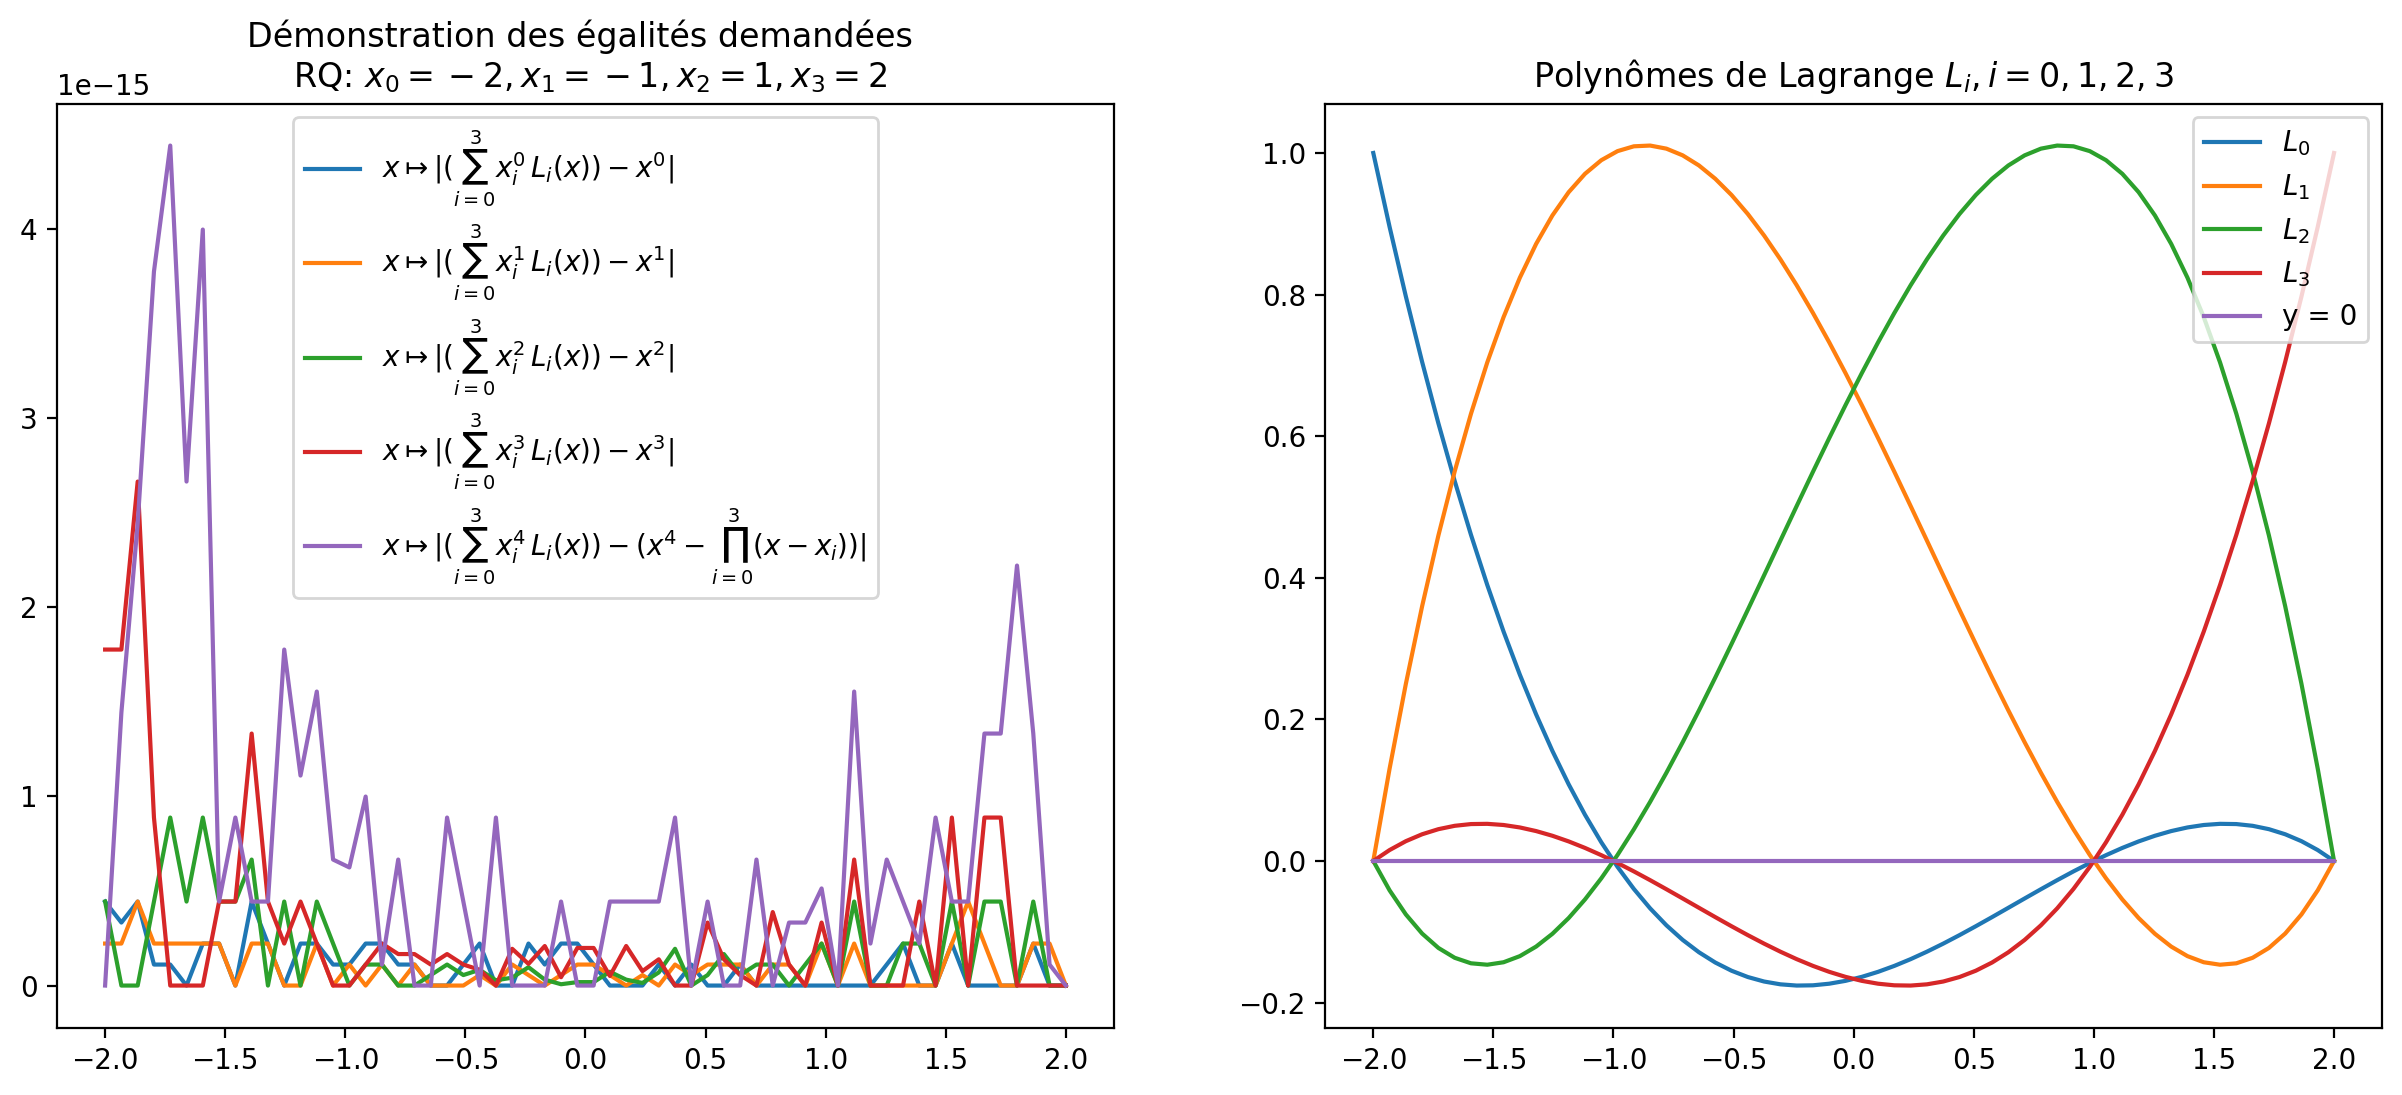

In [2]:
# UTILISEZ CETTE CELLULE POUR A QUESTION 1-2 . 
# VOUS POURREZ AUSSI AJOUTER DES CELLULES SUPPLEMENTAIRES MTOUT EN LES COMMENTANT

#==========================================
#METHODE 1  : PAR REPRESENTATION GRAPHIQUE
#==========================================

from scipy.interpolate import lagrange

L0 = lagrange([-2., -1, 1, 2], [1., 0, 0, 0])
L1 = lagrange([-2., -1, 1, 2], [0., 1, 0, 0])
L2 = lagrange([-2., -1, 1, 2], [0., 0, 1, 0])
L3 = lagrange([-2., -1, 1, 2], [0., 0, 0, 1])

#fig, ax = plt.subplots(1,2, figsize=(15,6))  # ON PEUT UTILISER CECI MAIS QULEQUE C'EST AUSSI SIMPLE
                                              # D'UTILISER  plt.... 

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
xx  = np.linspace(-2., 2, 60)
for k in range(4) :
    yy = (-2)**k *  L0(xx) + (-1)**k * L1(xx) + (1**k) * L2(xx) + (2**k) * L3(xx) - xx**k
    #plt.plot(xx, np.abs(yy) , label=f"Pour $k = {k:1}$")
    plt.plot(xx, np.abs(yy) , label=f'$x\mapsto |(\sum_{{{{i=0}}}}^3 x_i^{k} \, L_i(x) ) - x^{k} |$')
 
yy = (-2)**4 *  L0(xx) + (-1)**4 * L1(xx) + (1**3) * L2(xx) + (2**4) * L3(xx) - xx**4
yy = yy + (xx + 2) * (xx + 1) * (xx -1) * (xx - 2)
#plt.plot(xx, np.abs(yy), label="Pour $k = 4$")
plt.plot(xx, np.abs(yy) , label=f"$x\mapsto |(\sum_{{{{i=0}}}}^3 x_i^{4} \, L_i(x)) - (x^{4} - \prod_{{{{i=0}}}}^3 (x - x_i) )|$")

plt.legend()
plt.title ("Démonstration des égalités demandées \n RQ: $x_0 = -2, x_1 = -1, x_2 = 1, x_3 = 2$")

plt.subplot(1,2,2)
xx  = np.linspace(-2, 2, 60)
plt.plot(xx, L0(xx), label="$L_0$")
plt.plot(xx, L1(xx), label="$L_1$")
plt.plot(xx, L2(xx), label="$L_2$")
plt.plot(xx, L3(xx), label="$L_3$")
plt.plot(xx, 0. * xx, label="y = 0")
plt.title ("Polynômes de Lagrange $L_i, i = 0, 1, 2, 3$")
plt.legend()
plt.show()

In [3]:
#==========================================
#METHODE 2  : PAR CALCUL ALGEBRIQUE 
#==========================================
# ICI ON MONTRE QUE LA DIFFERENCE ENTRE MEMBRE de GAUCHE ET MEMBRE DE DROITE ESt NULLE

from scipy.interpolate import lagrange

L0 = lagrange([-2., -1, 1, 2], [1., 0, 0, 0])
L1 = lagrange([-2., -1, 1, 2], [0., 1, 0, 0])
L2 = lagrange([-2., -1, 1, 2], [0., 0, 1, 0])
L3 = lagrange([-2., -1, 1, 2], [0., 0, 0, 1])

px = np.poly1d([1,0])
for k in range(4) :
    print( f"================== Vérification pour k = {k} ================")
    P = (-2)**k *  L0 + (-1)**k * L1 + (1**k) * L2 + (2**k) * L3 - px**k
    print(f"(-2)^{k:1d} L_0 + (-1)^{k:1d}  L_1 + 1^{k:1d}  L_2 + 2^{k:1d}  L_3  - x^{k} = ")
    print(P)
    print (f" On a donc un polynôme de coefficients = {P.coeffs}")

print( f"================== Vérification pour k = {4} ================")
P = (-2)**4 *  L0 + (-1)**4 * L1 + (1**4) * L2 + (2**4) * L3 - px**4  + (px +2) * (px+1) *(px -1) * (px -2)
print(f"(-2)^4 L0 + (-1)^4  L1 + 1^4  L2 + 2^4  L3  - x^4 + (x+2)(x+1)(x-1)(x-2) ) = {P}")
print (f" On a donc un polynôme de coefficients = {P.coeffs}")


================== Vérification pour k = 0 ================
(-2)^0 L_0 + (-1)^0  L_1 + 1^0  L_2 + 2^0  L_3  - x^0 = 
 
1.388e-16 x - 1.11e-16
 On a donc un polynôme de coefficients = [ 1.38777878e-16 -1.11022302e-16]
================== Vérification pour k = 1 ================
(-2)^1 L_0 + (-1)^1  L_1 + 1^1  L_2 + 2^1  L_3  - x^1 = 
 
0
 On a donc un polynôme de coefficients = [0.]
================== Vérification pour k = 2 ================
(-2)^2 L_0 + (-1)^2  L_1 + 1^2  L_2 + 2^2  L_3  - x^2 = 
 
5.551e-17 x
 On a donc un polynôme de coefficients = [5.55111512e-17 0.00000000e+00]
================== Vérification pour k = 3 ================
(-2)^3 L_0 + (-1)^3  L_1 + 1^3  L_2 + 2^3  L_3  - x^3 = 
          2
2.22e-16 x
 On a donc un polynôme de coefficients = [2.22044605e-16 0.00000000e+00 0.00000000e+00]
================== Vérification pour k = 4 ================
(-2)^4 L0 + (-1)^4  L1 + 1^4  L2 + 2^4  L3  - x^4 + (x+2)(x+1)(x-1)(x-2) ) =  
0
 On a donc un polynôme de coefficients = [0

## Exercice 2 :  Interpolation de Lagrange et Différences divisées


Soit f une fonction connue par sa table des différences divisées. 
Les points d'interpolations sont $x_i = 0, 1, 2, 3,\ldots, 99, 100$.
Et on désigne par $f_i$ la valeur de $f(x_i)$.

Avec les seules informations suivantes : 

 > $f_0 = 12,\quad f_1 = 19,\quad  f_2 = 44$, 
 > les différences divisées du second ordre encore appelées *secondes différences divisées* sont constantes ( i.e les entrées de la 4-ième colonne (associée à $f_{[i,i+1,i+2]}$ ci-dessous) sont identiques),


  | $$ x_i$$ |  $$f_i $$    |  $$f_{[i,i+1]} $$ | $$f_{[i,i+1,i+2]}$$ | $$\ldots$$  
  |  :-:     |  :-:         |  :-:              | :-:                 | :-:
  |  0       |  12          |   $-$             | $-$                 | $\ldots$  
  |  1       |  19          | $\cdot$           | $-$                 | $\ldots$  
  |  2       |  44          | $\cdot$           | $\cdot$             | $\ldots$    
  | $\vdots$ | $\vdots$     | $\vdots$          | $\vdots$            | $\ldots$





#### Question 2-1 : A faire sur la copie d'examen  
> Montrer que $\qquad \mathbf { f_{49} = 21523 }.\qquad $  
>> **On rappelle que $\quad 9\times 48 \times 49 = 21 168$,   $\qquad 7\times 49 = 343$.**


<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;">

> - Comme la seconde différence divisée est constante, $f$ est donc polynômiale de degré 2. Donc coïncide avec son polynôme d'interpolation de Lagrange associé à 3 points. 
> - Ainsi la table des différences divisées suivante est suffisante :

  | $$ x_i$$ |  $$f_i $$    |  $$f_{[i,i+1]} $$ | $$f_{[i,i+1,i+2]}$$   
  |  :-:     |  :-:         |  :-:              | :-:                
  |  0       |  12          |  $-$              | $-$                   
  |  1       |  19          | $\frac{19 - 12}{1 - 0} = 7$           | $-$                  
  |  2       |  44          | $\frac{44 - 19}{2 - 1} = 25$           | $\frac{25 - 7}{2 - 0} = 9$                 
  

> - D'où l'expression de $f$ donnée dans la base de Newton : 
    
$$ f(x) = 12 + 7 x  +  9 x (x - 1)$$ 

> - Et $ f_{49} = f(49) = 12 + 7 \times 49 + 9 \times 48 \times 49 = 12 + 343 + 21168 = 21523$
</div>


#### Question 2-2 :  Cette partie est à faire sur ce notebook 
> Validation numérique de la question précédentes 
>> 1. Tracez la courbe représentative de la fonction $f$ sur l'intervalle $[0,100]$. Et placez le point $(49, 21523)$.
>> 2. Tracez sur le même graphique la droite horizontale $y = 21523$ et la droite vertcale $x = 49$. 

#### Question 2-3 :  Cette partie est à faire sur ce notebook
> Résolution de l'équation  $f(x) - 983.25 = 0 $
>> 1. En utilisant une approche de votre choix, déterminez une approximation du point $r$ tel que $f(r) - 983.25 = 0 $.
>> 2. Vérifiez votre résultat à l'aide d'une figure. (*On pourra représenter la fonction f et le point $(r, f(r))$ sur le même graphique*)
       

f( 49 ) = 21523


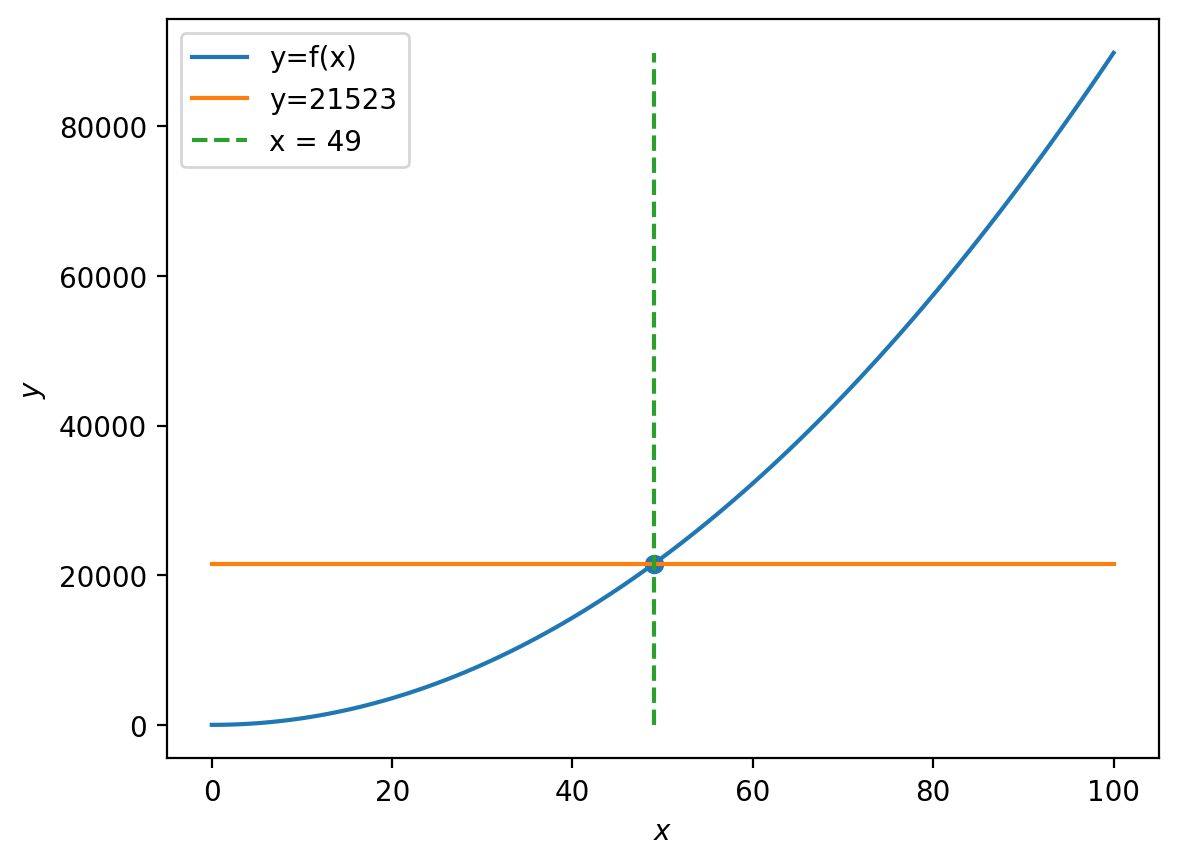

In [4]:
# UTILISEZ CETTE CELLULE POUR A QUESTION 2-2 . 
# VOUS POURREZ AUSSI AJOUTER DES CELLULES SUPPLEMENTAIRES TOUT EN LES COMMENTANT


def P(x):
    return 12 + 7 * x + 9 * x  * (x - 1)


print(f"f( {49:d} ) = {P(49):d}")    

xx = np.linspace(0,100.,101)
plt.plot(xx, P(xx), label="y=f(x)")

plt.plot(xx, 0*xx + 21523, label="y=21523")
#plt.plot([49,49], [0, 21523], '--', label="x = 49")
plt.plot(0 * xx + 49, P(xx), '--', label="x = 49")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("")

plt.scatter(49, P(49))
plt.legend()
plt.show()

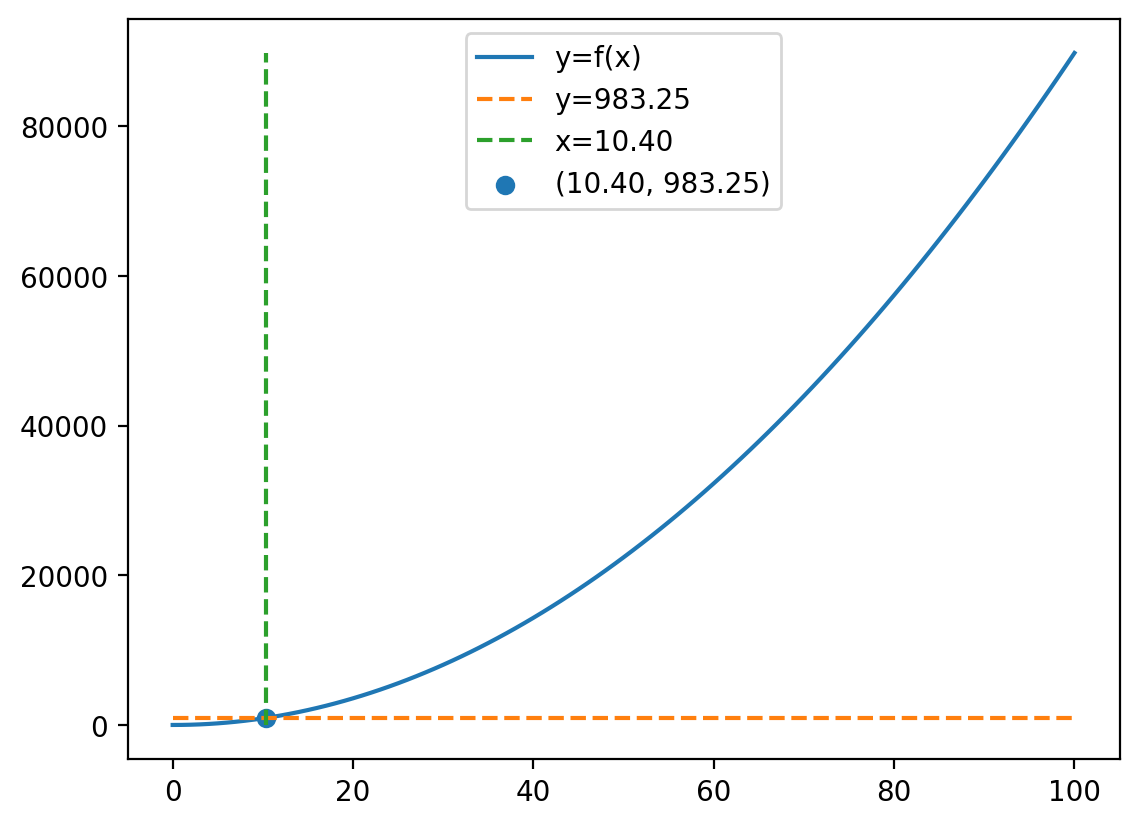

In [5]:
# UTILISEZ CETTE CELLULE POUR A QUESTION 2-3 . 
# VOUS POURREZ AUSSI AJOUTER DES CELLULES SUPPLEMENTAIRES TOUT EN LES COMMENTANT


# f(r) - 983.25 =  0  <=> f(r) = 983.25 <=> r = f^-1 (983.25)
# On va approcher f^-1 par un polynôme d'interpolation 
# Comme on ne sait pas si c'est un polynôme, on va utiliser plusieurs points d'interpolation 
# et se reposer sur l'interpolateur de Lagrange fourni pas Python 

from scipy.interpolate import lagrange

# On définit suffisamment de points d'interpolation
xi=[]
yi=[]

for i in range(100):
    xi.append(float(i))
    yi.append(P(xi[-1]))

# On définit l'interpolation inverse (c-a-d une interpolation de l'inverse)
Q = lagrange(yi, xi)

# On utilise l'interpolation inverse pour
fr = 983.25
r = Q(fr)

# On construit les graphiques
plt.plot(xx, P(xx), label="y=f(x)")
plt.plot(xx, 0*xx + fr, '--', label=f"y={fr:.2f}")
plt.plot(0*xx+r, P(xx), '--', label=f"x={r:.2f}")
plt.scatter(r, 983.25, label=f"({r:.2f}, 983.25)")
plt.legend()
plt.show()


<div style="color:#6a0eba;font-family:courier; font-size:100%; font-weight:bold;">
    
 > **Remarque**: On peut utiliser l'exercice ci-dessous pour fournir une meilleure à la question ci-dessus
    
</div>

## Exercice 3 :  Interpolation inverse et son application 
Dans certaines situations, on peut être amené à définir l'interpolation de la fonction réciproque,
en exploitant la table des différences divisées, et son utilité peut être non négligeable. 

On appelle **polynôme d'interpolation inverse**, associé aux points $(x_i, y_i), i=0,\ldots, n$ où les 
$y_i, i=0,\ldots n$ comme les $x_i$ sont 2 à 2 distincts, le polynôme d'interpolation $Q_n$ associé aux points $(y_i, x_i), i=0,\ldots, n$.
(**Il est important de bien observer ici qu'on a interchangé les positions de $y_i$ et $x_i$**). 

### Question 3-1 :  Aspect théorique ( à faire sur la copie )

On va analyser ce polynôme d'interpolation inverse dans le cas d'interpolation avec 2 points.

On considère une fonction f de classe $C^2$ telle que $f^{'}(x) \neq 0$ pour tout  $x_0 < x < x_1$. 
Et $y_0 = f(x_0), y_1 = f(x_1)$.

On désigne par $g$ la fonction réciproque de $f$. C'est-à-dire $g (y) = f^{-1}(y) \quad \forall y \in [y_0, y_1]$.


> 1. Montrer que si $ y = f(x)$ alors  $\displaystyle g^{''}(y) = - \frac{f^{''}(x)}{(f^{'}(x))^3} $

> 2. Montrer en utilisant le résultat sur l'erreur d'interpolation polynômiale que
    Si $Q_1$ est le polynôme d'interpolation inverse de degré 1 associé aux points $(x_0, y_0)$ et $(x_1, y_1)$
    alors  il existe $\xi \in ]x_0, x_1[$ tel que 
$$ 
      g(y) - Q_1(y)  = - (y - y_0) (y - y_1)   \frac{ f^{''}(\xi) } { 2 ( f^{'}(\xi) )^3  } \quad \forall y \in [y_0, y_1]
$$

> 3. On suppose qu'il existe des réels positifs $m_1, M_1, M_2$ tels que $m_1 \leq | f^{'}(x) | \leq M_1, \quad |f^{''}(x) |\leq M_2 \quad \forall x\in [x_0, x_1]$. 

>> 3-1. Montrer que   $$ |g(y) - Q_1(y) | \leq  \frac{(y_1 - y_0)^2}{8} \frac{M_2}{m_1^3}  \quad \forall y\in [y_0, y_1] $$
>> 3-2. En déduire que  $$ |g(y) - Q_1(y) | \leq  \frac{(x_1 - x_0)^2}{8} \left(\frac{M_1}{m_1}\right)^2 \left( \frac{M_2}{m_1}\right)  \quad \forall y\in [y_0, y_1] $$

> 4. Pouvez-vous présenter une utilité de ce résultat ?

--- 
 > # =============== FIN ====================
---